# EEG movement decoding dataset — exploratory visualization

This notebook loads the **processed** cue-locked EEG epochs written by `build_dataset.py` (`data/processed/dataset_train.npz` and `dataset_test.npz`). Each trial is shaped **(channels × time)** after:

- Picking EEG channels only, applying a **common average reference**, and causal **band-pass filtering** in the $\mu$-band (see `bandpass_hz` in the NPZ).
- Epoch extraction from annotated cue events (`epoch_tmin` … `epoch_tmax` seconds relative to cue), with amplitude-based rejection of bad trials.

**Goals here:** inspect **grand-average waveforms** (mean ± dispersion across trials) for each movement/rest class on the **same axes**, summarize **which electrodes contribute most** in a chosen post-cue window, and draw **scalp topomaps** of those patterns.

> Tip: rerun `python build_dataset.py` after changing preprocessing in `config.py` so plots stay aligned with the saved tensors.

---
## Setup

Paths, imports, plotting defaults. Uses the project virtualenv (`mne`, `numpy`, `matplotlib`).

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Project root: parent of notebooks/
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import mne
from scipy.stats import mannwhitneyu

# Style
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 160,
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 12,
        "legend.fontsize": 10,
        "axes.grid": True,
        "grid.alpha": 0.25,
    }
)

PROC = ROOT / "data" / "processed"
TRAIN_NPZ = PROC / "dataset_train.npz"
TEST_NPZ = PROC / "dataset_test.npz"

for path in (TRAIN_NPZ, TEST_NPZ):
    if not path.is_file():
        raise FileNotFoundError(f"Expected processed file missing: {path}")

---
## Loading tensors and bookkeeping

We concatenate **train + test** for visualization (maximum SNR on averages). Labels `y` are integers `0 … n_classes − 1` aligned with `class_names`. Time samples run from `epoch_tmin` to `epoch_tmax` at sampling rate `sfreq`.

In [3]:

def load_split(path: Path) -> dict[str, np.ndarray]:
    with np.load(path, allow_pickle=True) as z:
        return {k: z[k] for k in z.files}


def merge_splits(paths: list[Path]) -> dict[str, np.ndarray]:
    parts = [load_split(p) for p in paths]
    merged = {
        "X": np.concatenate([p["X"] for p in parts], axis=0),
        "y": np.concatenate([p["y"] for p in parts], axis=0),
    }
    # Metadata identical across splits; take first file
    meta_keys = [
        "sfreq",
        "ch_names",
        "class_names",
        "epoch_tmin",
        "epoch_tmax",
        "bandpass_hz",
        "reject_eeg_uv",
    ]
    base = parts[0]
    for k in meta_keys:
        merged[k] = base[k]
    return merged


bundle = merge_splits([TRAIN_NPZ, TEST_NPZ])
X = bundle["X"]
y = bundle["y"]
sfreq = float(bundle["sfreq"][0])
ch_names = list(bundle["ch_names"])
class_names = list(bundle["class_names"])
tmin = float(bundle["epoch_tmin"][0])
tmax = float(bundle["epoch_tmax"][0])
bp = tuple(float(x) for x in bundle["bandpass_hz"])
n_trials, n_ch, n_times = X.shape
times_s = np.arange(n_times, dtype=float) / sfreq + tmin

assert X.ndim == 3 and len(y) == n_trials

print(f"Merged trials: {n_trials}  |  EEG shape: ({n_trials}, {n_ch}, {n_times})")
print(f"sfreq = {sfreq:.1f} Hz  |  window [{tmin:.2f}, {tmax:.2f}] s  |  band-pass {bp[0]}-{bp[1]} Hz")
print(f"Classes ({len(class_names)}): {class_names}")
unique, counts = np.unique(y, return_counts=True)
for c, n in zip(unique, counts):
    print(f"  {int(c):d} {class_names[int(c)]}: {int(n)} trials")

Merged trials: 3151  |  EEG shape: (3151, 4, 1025)
sfreq = 256.0 Hz  |  window [-2.00, 2.00] s  |  band-pass 3.0-30.0 Hz
Classes (4): ['elbow_flex_ext', 'hand_open_close', 'forearm_sup_pron', 'rest']
  0 elbow_flex_ext: 950 trials
  1 hand_open_close: 848 trials
  2 forearm_sup_pron: 874 trials
  3 rest: 479 trials


In [4]:
from mne.decoding import CSP

# 1. Fit the CSP as usual
csp = CSP(n_components=4, reg=None, log=True, norm_trace=False)
csp.fit(X, y)

Computing rank from data with rank=None
    Using tolerance 2.4e-05 (2.2e-16 eps * 4 dim * 2.7e+10  max singular value)
    Estimated rank (data): 4
    data: rank 4 computed from 4 data channels with 0 projectors
Reducing data rank from 4 -> 4
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.


,n_components,4
,reg,None
,log,True
,cov_est,'concat'
,transform_into,'average_power'
,norm_trace,False
,cov_method_params,None
,restr_type,'restricting'
,info,None
,rank,None
,component_order,'mutual_info'


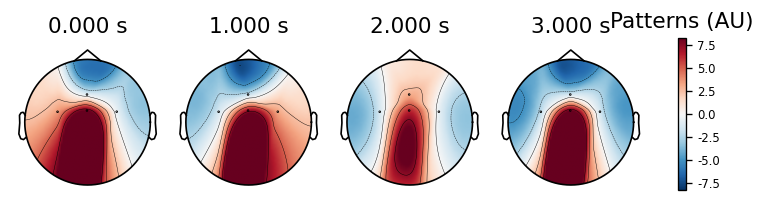

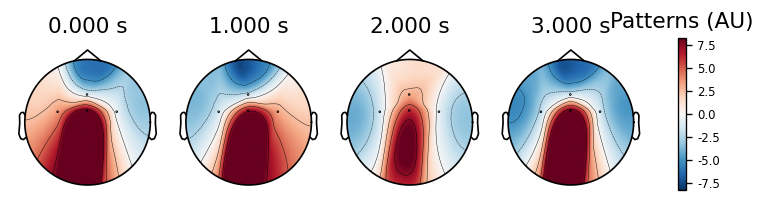

In [5]:
# 2. Manually compute the patterns from the filters
# Patterns explain how the sources project to the electrodes
patterns = np.linalg.pinv(csp.filters_).T

# 3. Create the Info object (ensure ch_names matches your X array)
ch_names = [
    'FCz', 'C3', 'C4', 'Cz'
]
info = mne.create_info(ch_names=ch_names, sfreq=1, ch_types='eeg')
info.set_montage(mne.channels.make_standard_montage('standard_1005'))

# 4. Create an EvokedArray object to hold the patterns
# We treat each CSP component as a 'time point' for plotting purposes
# 'patterns' has shape (n_channels, n_components)
evoked = mne.EvokedArray(patterns, info, tmin=0)

# 5. Plot the topomaps for the components (0, 1, 2, 3)
# This replaces csp.plot_patterns() and is much more stable
evoked.plot_topomap(times=np.arange(patterns.shape[1]).astype(float), 
                    ch_type='eeg', 
                    colorbar=True, 
                    units='Patterns (AU)',
                    time_unit='s',  # Use 's' (seconds) as the unit
                    nrows=1)

---
## Grand-average ERPs (mean ± std across trials)

For each class we average **across trials** at every time point. The shaded band is **±1 standard deviation across trials** (not the standard error of the mean), which is a common ERP convention for showing trial-wise spread.

Because the data are **CAR**-referenced, a single midline electrode (here **Cz**) is a familiar reference point. We also plot **global field power (GFP)** per trial (RMS over EEG channels with valid scalp positions) so all conditions share one summary trace that is not tied to one sensor.

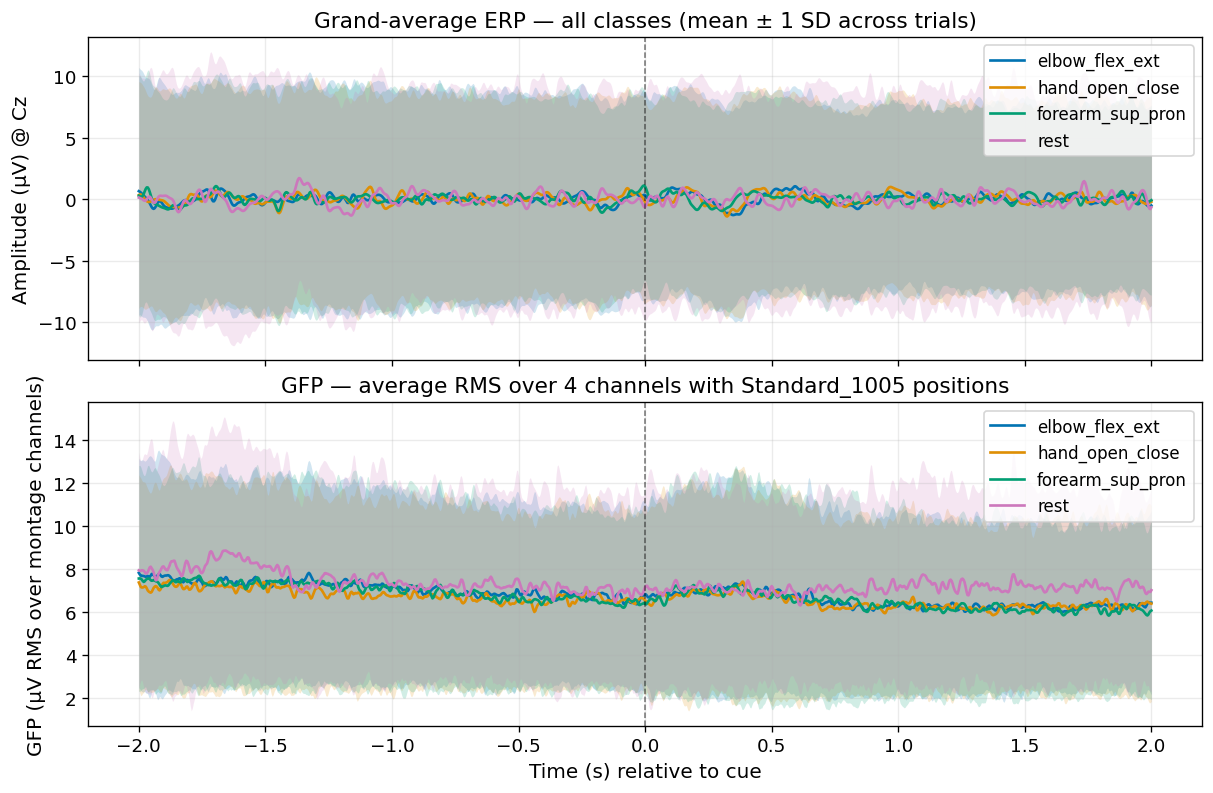

In [6]:

def erp_stats(data: np.ndarray, axis: int = 0) -> tuple[np.ndarray, np.ndarray]:
    """Mean and std across trials (or another axis)."""
    return np.mean(data, axis=axis), np.std(data, axis=axis, ddof=0)


PRIMARY_CH = "Cz"

# Montage-aligned channels for GFP (exclude named channels absent from Standard_1005)
montage_1005 = mne.channels.make_standard_montage("standard_1005")
montage_present = montage_1005.ch_names
eeg_idxs = [i for i, name in enumerate(ch_names) if name in montage_present]
gfp_ch_names = [ch_names[i] for i in eeg_idxs]

X_flat = np.sqrt(np.mean(np.square(X[:, eeg_idxs, :]), axis=1))

# Color cycle: colorblind-friendly
colors = [
    "#0173b2",
    "#de8f05",
    "#029e73",
    "#cc78bc",
    "#ca9161",
    "#949494",
    "#ece133",
    "#56b4e9",
][: len(class_names)]

fig, axes = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True, constrained_layout=True)

ax = axes[0]
ci = ch_names.index(PRIMARY_CH)
for k, name in enumerate(class_names):
    mask = y == k
    if not np.any(mask):
        continue
    m, s = erp_stats(X[mask, ci, :], axis=0)
    color = colors[k % len(colors)]
    ax.plot(times_s, m * 1e6, color=color, linewidth=1.6, label=name)
    ax.fill_between(times_s, (m - s) * 1e6, (m + s) * 1e6, color=color, alpha=0.18, linewidth=0)
ax.axvline(0.0, color="k", linestyle="--", linewidth=0.9, alpha=0.55)
ax.set_ylabel(f"Amplitude (µV) @ {PRIMARY_CH}")
ax.set_title("Grand-average ERP — all classes (mean ± 1 SD across trials)")
ax.legend(frameon=True, loc="upper right")

ax = axes[1]
for k, name in enumerate(class_names):
    mask = y == k
    if not np.any(mask):
        continue
    m, s = erp_stats(X_flat[mask], axis=0)
    color = colors[k % len(colors)]
    ax.plot(times_s, m * 1e6, color=color, linewidth=1.6, label=name)
    ax.fill_between(times_s, (m - s) * 1e6, (m + s) * 1e6, color=color, alpha=0.18, linewidth=0)
ax.axvline(0.0, color="k", linestyle="--", linewidth=0.9, alpha=0.55)
ax.set_xlabel("Time (s) relative to cue")
ax.set_ylabel("GFP (µV RMS over montage channels)")
ax.set_title(
    f"GFP — average RMS over {len(gfp_ch_names)} channels with Standard_1005 positions"
)
ax.legend(frameon=True, loc="upper right")

plt.show()